Step 1 — Video input and quality — check Load the video file using OpenCV. For every frame check three things — is the face detectable,
is the face large enough to extract reliable eye landmarks, and is the lighting sufficient. Any
frame that fails these checks gets flagged as unusable and skipped. At the end of this step you
know what percentage of the video is usable. If less than 70% of frames are usable you flag the
entire submission as low confidence and warn the director that eye metrics are unreliable for this
video


In [1]:
# Install dependencies
!pip install mediapipe==0.10.20

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 9.7 MB/s eta 0:00:00
  Att

In [1]:
import cv2
import mediapipe as mp
import numpy as np
from google.colab import files
import os

In [59]:
# ============================================================
# Upload your video
# ============================================================

print("Please upload your audition video...")
uploaded = files.upload()
video_filename = list(uploaded.keys())[0]
print(f"Video uploaded: {video_filename}")

# ============================================================
# Configuration — adjust these thresholds as needed
# ============================================================

CONFIG = {
    "min_face_size_ratio": 0.10,   # face must be at least 10% of frame height
    "min_detection_confidence": 0.5,
    "min_usable_frame_ratio": 0.70, # at least 70% of frames must be usable
    "max_head_angle_degrees": 30,   # flag if head turns more than 30 degrees
}

# ============================================================
# Initialize MediaPipe Face Mesh
# ============================================================

mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,       # video mode - faster
    max_num_faces=1,               # we only care about the actor
    refine_landmarks=True,         # gives us iris landmarks too
    min_detection_confidence=CONFIG["min_detection_confidence"],
    min_tracking_confidence=0.5
)

# ============================================================
# Helper functions
# ============================================================

def get_face_size(landmarks, frame_height, frame_width):
    """
    Estimates face size as a ratio of frame height.
    Uses the vertical distance between forehead and chin landmarks.
    """
    # Forehead top ~ landmark 10, chin bottom ~ landmark 152
    forehead = landmarks[10]
    chin = landmarks[152]

    face_height_pixels = abs(forehead.y - chin.y) * frame_height
    face_ratio = face_height_pixels / frame_height

    return face_ratio


def get_head_angle(landmarks):
    """
    Estimates horizontal head rotation using nose tip and ear landmarks.
    Returns angle in degrees — 0 means perfectly front-facing.
    """
    # Nose tip ~ landmark 1
    # Left ear ~ landmark 234, Right ear ~ landmark 454
    nose = landmarks[1]
    left_ear = landmarks[234]
    right_ear = landmarks[454]

    # Distance from nose to each ear
    dist_left = abs(nose.x - left_ear.x)
    dist_right = abs(nose.x - right_ear.x)

    # If perfectly front-facing, both distances are equal
    # Ratio tells us how much the head is turned
    total = dist_left + dist_right
    if total == 0:
        return 0

    ratio = abs(dist_left - dist_right) / total

    # Convert ratio to approximate degrees (0 = front, 1 = full profile)
    angle_degrees = ratio * 90

    return angle_degrees


def check_lighting(frame):
    """
    Checks if lighting is sufficient for reliable landmark detection.
    Returns True if lighting is acceptable.
    """
    # Convert to grayscale and check average brightness
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    avg_brightness = np.mean(gray)

    # Too dark (below 40) or too bright/overexposed (above 220)
    if avg_brightness < 40 or avg_brightness > 220:
        return False
    return True


def classify_skip_reason(face_detected, face_large_enough,
                          lighting_ok, angle_ok):
    """
    Returns a human-readable reason why a frame was skipped.
    """
    if not face_detected:
        return "no_face_detected"
    if not face_large_enough:
        return "face_too_small"
    if not lighting_ok:
        return "poor_lighting"
    if not angle_ok:
        return "head_angle_too_large"
    return None

# ============================================================
# Main quality check loop
# ============================================================

def run_quality_check(video_path):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("ERROR: Could not open video file.")
        return None

    # Video metadata
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration_seconds = total_frames / fps

    print(f"\nVideo info:")
    print(f"  Resolution   : {frame_width} x {frame_height}")
    print(f"  FPS          : {fps:.1f}")
    print(f"  Total frames : {total_frames}")
    print(f"  Duration     : {duration_seconds:.1f} seconds")
    print(f"\nRunning quality check...")

    # Tracking variables
    usable_frames = []
    skipped_frames = []
    skip_reasons = {
        "no_face_detected": 0,
        "face_too_small": 0,
        "poor_lighting": 0,
        "head_angle_too_large": 0
    }

    frame_index = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        timestamp_ms = cap.get(cv2.CAP_PROP_POS_MSEC)

        # --- Check 1: Lighting ---
        lighting_ok = check_lighting(frame)

        # --- Check 2: Face detection ---
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_frame)

        face_detected = results.multi_face_landmarks is not None
        face_large_enough = False
        angle_ok = False

        if face_detected:
            landmarks = results.multi_face_landmarks[0].landmark

            # --- Check 3: Face size ---
            face_ratio = get_face_size(landmarks, frame_height, frame_width)
            face_large_enough = face_ratio >= CONFIG["min_face_size_ratio"]

            # --- Check 4: Head angle ---
            head_angle = get_head_angle(landmarks)
            angle_ok = head_angle <= CONFIG["max_head_angle_degrees"]

        # --- Classify this frame ---
        all_checks_passed = (face_detected and face_large_enough
                             and lighting_ok and angle_ok)

        if all_checks_passed:
            usable_frames.append({
                "frame_index": frame_index,
                "timestamp_ms": timestamp_ms,
                "landmarks": results.multi_face_landmarks[0].landmark
            })
        else:
            reason = classify_skip_reason(
                face_detected, face_large_enough, lighting_ok, angle_ok
            )
            skip_reasons[reason] += 1
            skipped_frames.append({
                "frame_index": frame_index,
                "timestamp_ms": timestamp_ms,
                "reason": reason
            })

        frame_index += 1

    cap.release()

    # ============================================================
    # Quality report
    # ============================================================

    total_processed = len(usable_frames) + len(skipped_frames)
    usable_ratio = len(usable_frames) / total_processed if total_processed > 0 else 0
    video_is_usable = usable_ratio >= CONFIG["min_usable_frame_ratio"]

    report = {
        "video_path": video_path,
        "fps": fps,
        "frame_width": frame_width,
        "frame_height": frame_height,
        "duration_seconds": duration_seconds,
        "total_frames": total_processed,
        "usable_frames": len(usable_frames),
        "skipped_frames": len(skipped_frames),
        "usable_ratio": usable_ratio,
        "skip_reasons": skip_reasons,
        "video_is_usable": video_is_usable,
        "usable_frame_data": usable_frames  # passed to Step 2
    }

    # Print report
    print(f"\n{'='*45}")
    print(f"  QUALITY CHECK REPORT")
    print(f"{'='*45}")
    print(f"  Usable frames    : {len(usable_frames)} / {total_processed} ({usable_ratio*100:.1f}%)")
    print(f"  Skipped frames   : {len(skipped_frames)}")

    if len(skipped_frames) > 0:
        print(f"\n  Skip reasons:")
        for reason, count in skip_reasons.items():
            if count > 0:
                print(f"    - {reason}: {count} frames")

    print(f"\n  {'PASS - Video is usable' if video_is_usable else 'FAIL - Video quality too low'}")

    if not video_is_usable:
        print(f"\n  WARNING: Only {usable_ratio*100:.1f}% of frames are usable.")
        print(f"  Eye metrics will not be reliable for this submission.")
        print(f"  Advise the actor to resubmit with better lighting")
        print(f"  and face the camera more directly.")

    print(f"{'='*45}\n")

    return report


# ============================================================
# Run it
# ============================================================

report = run_quality_check(video_filename)

Please upload your audition video...


Saving WhatsApp Video 2026-04-07 at 5.25.34 PM.mp4 to WhatsApp Video 2026-04-07 at 5.25.34 PM.mp4
Video uploaded: WhatsApp Video 2026-04-07 at 5.25.34 PM.mp4

Video info:
  Resolution   : 474 x 850
  FPS          : 30.1
  Total frames : 332
  Duration     : 11.0 seconds

Running quality check...

  QUALITY CHECK REPORT
  Usable frames    : 332 / 332 (100.0%)
  Skipped frames   : 0

  PASS - Video is usable



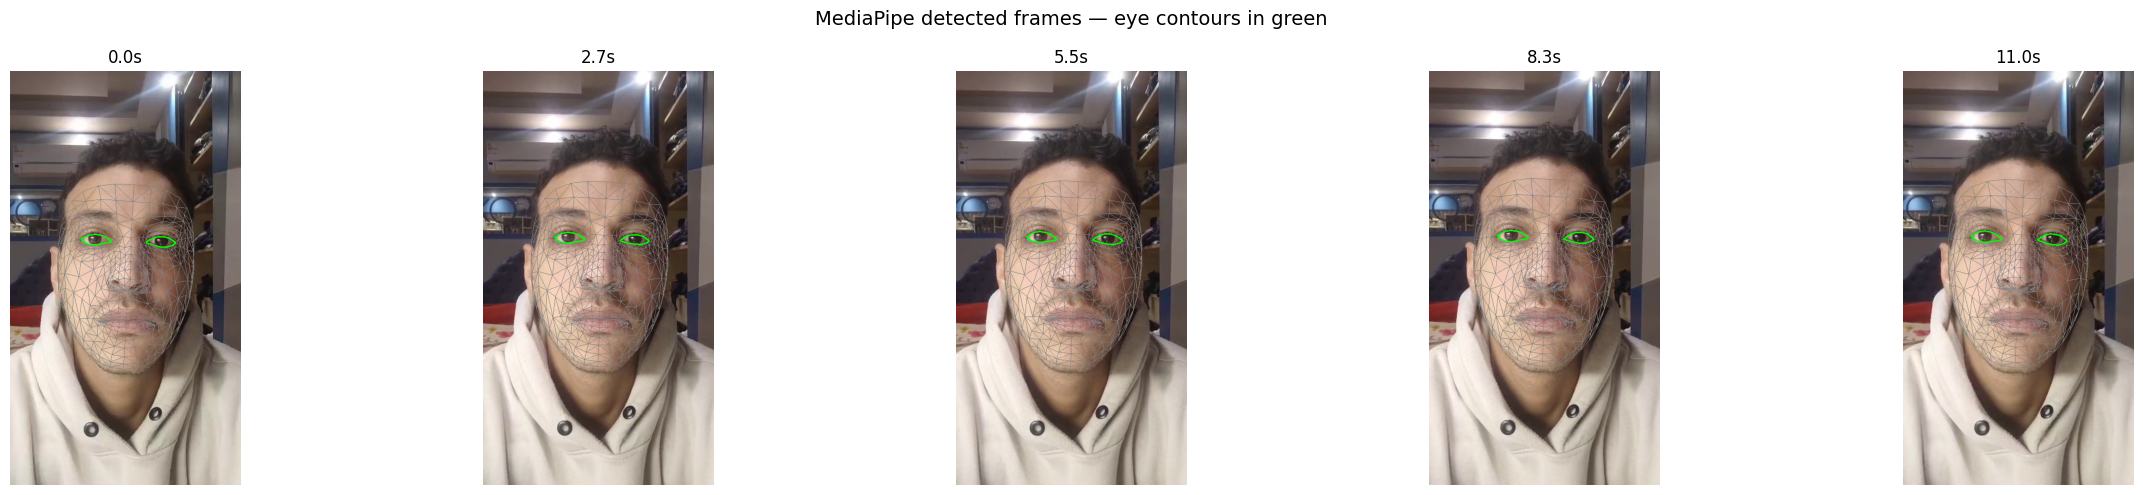

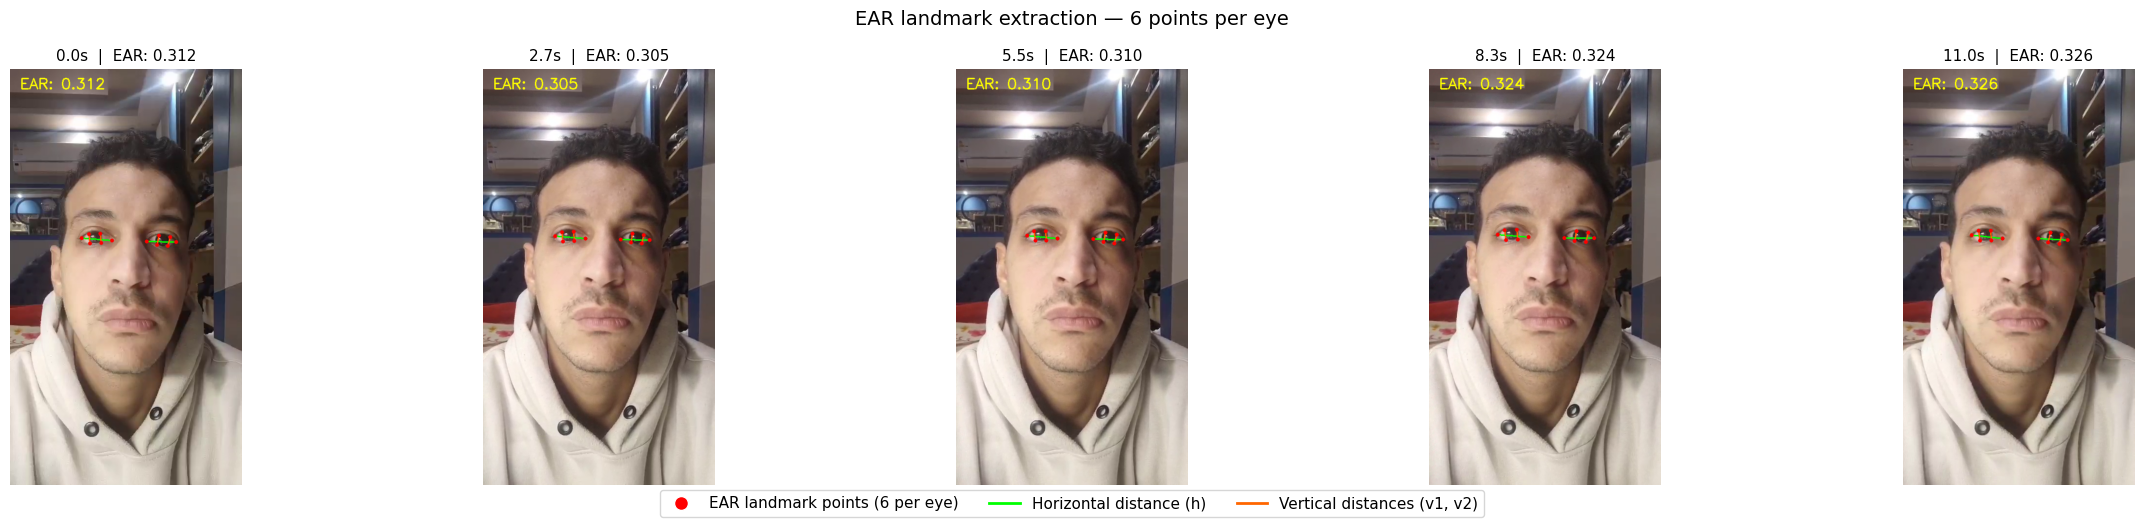

In [60]:
# ============================================================
# Visualize detected frames from MediaPipe
# ============================================================

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np

mp_face_mesh    = mp.solutions.face_mesh
mp_drawing      = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

def visualize_detected_frames(video_path, report, num_frames=5):
    """
    Pulls evenly spaced frames from the usable frames list,
    runs MediaPipe drawing on them, and displays them in a grid.

    num_frames : how many frames you want to see
    """

    usable_frames = report["usable_frame_data"]

    if len(usable_frames) == 0:
        print("No usable frames to display.")
        return

    # Pick evenly spaced frames from the usable list
    indices = np.linspace(0, len(usable_frames) - 1, num_frames, dtype=int)
    selected_frames = [usable_frames[i] for i in indices]

    cap = cv2.VideoCapture(video_path)

    fig, axes = plt.subplots(1, num_frames, figsize=(5 * num_frames, 5))
    if num_frames == 1:
        axes = [axes]

    face_mesh_drawer = mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    )

    for ax, frame_data in zip(axes, selected_frames):

        # Seek to the exact frame
        cap.set(cv2.CAP_PROP_POS_MSEC, frame_data["timestamp_ms"])
        ret, frame = cap.read()

        if not ret:
            ax.axis("off")
            continue

        # Convert to RGB for MediaPipe
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results   = face_mesh_drawer.process(rgb_frame)

        # Draw the mesh on the frame
        annotated = rgb_frame.copy()
        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:

                # Draw full tessellation (the mesh grid)
                mp_drawing.draw_landmarks(
                    image=annotated,
                    landmark_list=face_landmarks,
                    connections=mp_face_mesh.FACEMESH_TESSELATION,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp_drawing_styles
                        .get_default_face_mesh_tesselation_style()
                )

                # Draw the eye contours on top in a distinct color
                mp_drawing.draw_landmarks(
                    image=annotated,
                    landmark_list=face_landmarks,
                    connections=mp_face_mesh.FACEMESH_LEFT_EYE,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp_drawing.DrawingSpec(
                        color=(0, 255, 0), thickness=2
                    )
                )
                mp_drawing.draw_landmarks(
                    image=annotated,
                    landmark_list=face_landmarks,
                    connections=mp_face_mesh.FACEMESH_RIGHT_EYE,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp_drawing.DrawingSpec(
                        color=(0, 255, 0), thickness=2
                    )
                )

        timestamp_sec = frame_data["timestamp_ms"] / 1000
        ax.imshow(annotated)
        ax.set_title(f"{timestamp_sec:.1f}s", fontsize=12)
        ax.axis("off")

    cap.release()
    face_mesh_drawer.close()
    plt.suptitle("MediaPipe detected frames — eye contours in green", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# Run it — change num_frames to see more or fewer
# ============================================================

visualize_detected_frames(video_filename, report, num_frames=5)
# ============================================================
# Visualize landmark extraction — EAR points highlighted
# ============================================================

def visualize_ear_landmarks(video_path, report, num_frames=5):
    """
    Shows the exact 6 landmark points used for EAR computation
    on each eye, with the vertical and horizontal lines drawn.

    Red dots   = the 6 EAR landmark points
    Green line = horizontal distance (h)
    Blue lines = vertical distances (v1, v2)
    """

    LEFT_EYE  = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE = [33,  160, 158, 133, 153, 144]

    usable_frames = report["usable_frame_data"]

    if len(usable_frames) == 0:
        print("No usable frames to display.")
        return

    indices        = np.linspace(0, len(usable_frames) - 1, num_frames, dtype=int)
    selected_frames = [usable_frames[i] for i in indices]

    cap = cv2.VideoCapture(video_path)

    face_mesh_drawer = mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    )

    fig, axes = plt.subplots(1, num_frames, figsize=(5 * num_frames, 5))
    if num_frames == 1:
        axes = [axes]

    for ax, frame_data in zip(axes, selected_frames):

        cap.set(cv2.CAP_PROP_POS_MSEC, frame_data["timestamp_ms"])
        ret, frame = cap.read()

        if not ret:
            ax.axis("off")
            continue

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results   = face_mesh_drawer.process(rgb_frame)
        annotated = rgb_frame.copy()

        h_img, w_img = annotated.shape[:2]

        if results.multi_face_landmarks:
            landmarks = results.multi_face_landmarks[0].landmark

            for eye_indices in [LEFT_EYE, RIGHT_EYE]:

                # Convert normalized coords to pixel coords
                pts = [
                    (int(landmarks[i].x * w_img),
                     int(landmarks[i].y * h_img))
                    for i in eye_indices
                ]

                # pts layout matches EAR formula:
                # pts[0] = left corner  (horizontal start)
                # pts[3] = right corner (horizontal end)
                # pts[1] & pts[5] = vertical pair 1 (upper & lower)
                # pts[2] & pts[4] = vertical pair 2 (upper & lower)

                # Draw horizontal line (green)
                cv2.line(annotated, pts[0], pts[3], (0, 255, 0), 2)

                # Draw vertical lines (blue)
                cv2.line(annotated, pts[1], pts[5], (255, 100, 0), 2)
                cv2.line(annotated, pts[2], pts[4], (255, 100, 0), 2)

                # Draw the 6 landmark dots (red)
                for pt in pts:
                    cv2.circle(annotated, pt, 4, (255, 0, 0), -1)

            # Compute and display EAR value on frame
            def dist(a, b):
                return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

            def compute_ear_pts(pts):
                v1 = dist(pts[1], pts[5])
                v2 = dist(pts[2], pts[4])
                h  = dist(pts[0], pts[3])
                if h == 0:
                    return 0.0
                return (v1 + v2) / (2.0 * h)

            left_pts  = [
                (int(landmarks[i].x * w_img), int(landmarks[i].y * h_img))
                for i in LEFT_EYE
            ]
            right_pts = [
                (int(landmarks[i].x * w_img), int(landmarks[i].y * h_img))
                for i in RIGHT_EYE
            ]

            left_ear  = compute_ear_pts(left_pts)
            right_ear = compute_ear_pts(right_pts)
            avg_ear   = (left_ear + right_ear) / 2.0

            cv2.putText(
                annotated,
                f"EAR: {avg_ear:.3f}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0, (255, 255, 0), 2
            )

        timestamp_sec = frame_data["timestamp_ms"] / 1000
        ax.imshow(annotated)
        ax.set_title(f"{timestamp_sec:.1f}s  |  EAR: {avg_ear:.3f}", fontsize=11)
        ax.axis("off")

    cap.release()
    face_mesh_drawer.close()

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
               markersize=10, label='EAR landmark points (6 per eye)'),
        Line2D([0], [0], color=(0, 1, 0), linewidth=2,
               label='Horizontal distance (h)'),
        Line2D([0], [0], color=(1, 0.4, 0), linewidth=2,
               label='Vertical distances (v1, v2)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle("EAR landmark extraction — 6 points per eye", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# Run it
# ============================================================

visualize_ear_landmarks(video_filename, report, num_frames=5)

Step 2 — Landmark extraction and EAR computation — On every usable frame run MediaPipe Face Mesh and extract the 6 landmark points for each eye.
Compute the Eye Aspect Ratio from those points using the formula — sum of two vertical
distances divided by twice the horizontal distance. Average the left and right eye EAR values
into one number per frame. Store every frame's EAR value alongside its timestamp in
milliseconds.
Output of this step: a time series array of shape [num_frames, 2] where each row is [timestamp, EAR value]


In [61]:
# ============================================================
# STEP 2 - Landmark Extraction and EAR Computation
# ============================================================

import numpy as np

# ============================================================
# MediaPipe landmark indices for each eye
# These are the 6 points used for EAR computation
# ============================================================

# Each eye needs: 2 vertical pairs + 1 horizontal pair
EYE_LANDMARKS = {
    "left": {
        "horizontal": [33, 133],       # left corner, right corner
        "vertical_1": [160, 144],      # upper & lower - pair 1
        "vertical_2": [158, 153],      # upper & lower - pair 2
    },
    "right": {
        "horizontal": [362, 263],      # left corner, right corner
        "vertical_1": [387, 373],      # upper & lower - pair 1
        "vertical_2": [385, 380],      # upper & lower - pair 2
    }
}

# ============================================================
# Helper functions
# ============================================================

def get_landmark_coords(landmarks, index, frame_width, frame_height):
    """
    Converts a MediaPipe landmark (normalized 0-1) to pixel coordinates.
    """
    lm = landmarks[index]
    return np.array([lm.x * frame_width, lm.y * frame_height])


def compute_ear(landmarks, eye, frame_width, frame_height):
    """
    Computes Eye Aspect Ratio for one eye.

    EAR = (||v1|| + ||v2||) / (2 × ||h||)

    Where:
      v1, v2 = vertical landmark distances (2 pairs)
      h      = horizontal landmark distance (corner to corner)
    """
    indices = EYE_LANDMARKS[eye]

    # Horizontal distance — eye width
    h_left  = get_landmark_coords(landmarks, indices["horizontal"][0], frame_width, frame_height)
    h_right = get_landmark_coords(landmarks, indices["horizontal"][1], frame_width, frame_height)
    horizontal = np.linalg.norm(h_left - h_right)

    # Vertical distance — pair 1
    v1_top = get_landmark_coords(landmarks, indices["vertical_1"][0], frame_width, frame_height)
    v1_bot = get_landmark_coords(landmarks, indices["vertical_1"][1], frame_width, frame_height)
    vertical_1 = np.linalg.norm(v1_top - v1_bot)

    # Vertical distance — pair 2
    v2_top = get_landmark_coords(landmarks, indices["vertical_2"][0], frame_width, frame_height)
    v2_bot = get_landmark_coords(landmarks, indices["vertical_2"][1], frame_width, frame_height)
    vertical_2 = np.linalg.norm(v2_top - v2_bot)

    # Guard against division by zero
    if horizontal == 0:
        return 0.0

    ear = (vertical_1 + vertical_2) / (2.0 * horizontal)
    return ear


def compute_average_ear(landmarks, frame_width, frame_height):
    """
    Averages left and right EAR into one value per frame.
    """
    left_ear  = compute_ear(landmarks, "left",  frame_width, frame_height)
    right_ear = compute_ear(landmarks, "right", frame_width, frame_height)
    return (left_ear + right_ear) / 2.0

# ============================================================
# Main Step 2 function
# ============================================================

def run_ear_extraction(quality_report):
    """
    Takes the output of Step 1 and produces a time series of EAR values.

    Input  : quality_report from Step 1
    Output : numpy array of shape [num_usable_frames, 2]
             each row = [timestamp_ms, avg_ear]
    """

    # --- Guard: check video passed quality check ---
    if not quality_report["video_is_usable"]:
        print("WARNING: Video failed quality check in Step 1.")
        print("EAR extraction will proceed but results are LOW CONFIDENCE.")

    usable_frames = quality_report["usable_frame_data"]
    frame_width   = quality_report["frame_width"]
    frame_height  = quality_report["frame_height"]

    if len(usable_frames) == 0:
        print("ERROR: No usable frames found. Cannot extract EAR.")
        return None

    print(f"Extracting EAR from {len(usable_frames)} usable frames...")

    # --- EAR extraction loop ---
    time_series = []

    for frame_data in usable_frames:
        timestamp_ms = frame_data["timestamp_ms"]
        landmarks    = frame_data["landmarks"]

        avg_ear = compute_average_ear(landmarks, frame_width, frame_height)

        time_series.append([timestamp_ms, avg_ear])

    # Convert to numpy array — shape: [num_frames, 2]
    time_series = np.array(time_series, dtype=np.float64)

    # ============================================================
    # Step 2 report
    # ============================================================

    ear_values  = time_series[:, 1]
    min_ear     = np.min(ear_values)
    max_ear     = np.max(ear_values)
    mean_ear    = np.mean(ear_values)

    print(f"\n{'='*45}")
    print(f"  EAR EXTRACTION REPORT")
    print(f"{'='*45}")
    print(f"  Frames processed : {len(time_series)}")
    print(f"  EAR min          : {min_ear:.4f}")
    print(f"  EAR max          : {max_ear:.4f}")
    print(f"  EAR mean         : {mean_ear:.4f}")
    print(f"  Time range       : {time_series[0,0]:.0f}ms → {time_series[-1,0]:.0f}ms")
    print(f"{'='*45}\n")

    return time_series


# ============================================================
# Run it
# ============================================================

ear_time_series = run_ear_extraction(report)

# ear_time_series shape: [num_frames, 2]
# ear_time_series[:, 0] → timestamps in ms
# ear_time_series[:, 1] → avg EAR values

Extracting EAR from 332 usable frames...

  EAR EXTRACTION REPORT
  Frames processed : 332
  EAR min          : 0.3015
  EAR max          : 0.3353
  EAR mean         : 0.3167
  Time range       : 0ms → 11015ms



Step 3 — Baseline establishment —
Take the full EAR time series and compute the median value across all usable frames. This is the
actor's personal baseline — their natural resting eye state. Also compute the 25th and 75th
percentile values. These give you the natural variation range of this actor's eyes during normal
non-extreme moments. Store these three values — median, 25th percentile, 75th percentile — as
the actor's eye profile.
Output of this step: three numbers — baseline, lower natural range, upper natural range



In [62]:
# ============================================================
# STEP 3 - Baseline Establishment
# ============================================================

import numpy as np

def run_baseline_establishment(ear_time_series):
    """
    Takes the EAR time series from Step 2 and computes the actor's
    personal eye profile — baseline + natural variation range.

    Input  : ear_time_series from Step 2, shape [num_frames, 2]
             col 0 = timestamp_ms, col 1 = EAR value
    Output : eye_profile dict with baseline, lower_range, upper_range
    """

    if ear_time_series is None or len(ear_time_series) == 0:
        print("ERROR: No EAR data found. Cannot establish baseline.")
        return None

    # Extract just the EAR values column
    ear_values = ear_time_series[:, 1]

    # ============================================================
    # Stage 0 — Filter out blink frames before baseline computation
    # Blinks drag the median down and produce a false baseline
    # ============================================================

    BLINK_THRESHOLD = 0.15
    blink_mask      = ear_values >= BLINK_THRESHOLD
    ear_values_clean = ear_values[blink_mask]

    if len(ear_values_clean) == 0:
        print("ERROR: No non-blink frames found. Cannot establish baseline.")
        return None

    # ============================================================
    # Core computation — three numbers, computed on clean data only
    # ============================================================

    baseline    = np.median(ear_values_clean)          # 50th percentile
    lower_range = np.percentile(ear_values_clean, 25)  # 25th percentile
    upper_range = np.percentile(ear_values_clean, 75)  # 75th percentile

    # ============================================================
    # Store as the actor's eye profile
    # ============================================================

    eye_profile = {
        "baseline":        baseline,
        "lower_range":     lower_range,
        "upper_range":     upper_range,
        "iqr":             upper_range - lower_range,
        "blink_threshold": BLINK_THRESHOLD,
        "total_frames":    len(ear_values),
        "clean_frames":    len(ear_values_clean),
        "blink_frames":    int(np.sum(~blink_mask))
    }

    # ============================================================
    # Step 3 report
    # ============================================================

    print(f"\n{'='*45}")
    print(f"  BASELINE ESTABLISHMENT REPORT")
    print(f"{'='*45}")
    print(f"  Total frames     : {len(ear_values)}")
    print(f"  Blink frames     : {eye_profile['blink_frames']} removed")
    print(f"  Clean frames     : {len(ear_values_clean)} used for baseline")
    print(f"  Baseline (median): {baseline:.4f}")
    print(f"  Lower range (p25): {lower_range:.4f}")
    print(f"  Upper range (p75): {upper_range:.4f}")
    print(f"  Natural spread   : {eye_profile['iqr']:.4f}")
    print(f"{'='*45}\n")

    return eye_profile


# ============================================================
# Run it
# ============================================================

eye_profile = run_baseline_establishment(ear_time_series)

# eye_profile["baseline"]        → actor's resting eye state (blink-free)
# eye_profile["lower_range"]     → bottom of normal variation
# eye_profile["upper_range"]     → top of normal variation
# eye_profile["blink_threshold"] → threshold used to filter blinks
# eye_profile["blink_frames"]    → how many blink frames were excluded


  BASELINE ESTABLISHMENT REPORT
  Total frames     : 332
  Blink frames     : 0 removed
  Clean frames     : 332 used for baseline
  Baseline (median): 0.3165
  Lower range (p25): 0.3121
  Upper range (p75): 0.3207
  Natural spread   : 0.0086



Step 4 — Normalize the curve —
Convert every raw EAR value in the time series into a percentage deviation from the baseline.
The formula is simply ((EAR - baseline) / baseline) × 100. Now every value in your time series
is a percentage. Zero means exactly at baseline. Positive means more open than natural. Negative
means more closed than natural. Apply a smoothing pass using a rolling average over 15 frames
— roughly half a second at 30fps — to remove single-frame noise while preserving the real
emotional movements which are sustained over multiple seconds

In [63]:
# ============================================================
# STEP 4 - Normalize the Curve
# ============================================================

import numpy as np

def run_normalization(ear_time_series, eye_profile):

    if ear_time_series is None or eye_profile is None:
        print("ERROR: Missing input from Step 2 or Step 3.")
        return None

    timestamps = ear_time_series[:, 0]
    ear_values = ear_time_series[:, 1]
    baseline   = eye_profile["baseline"]

    # ============================================================
    # Stage 0 — Filter out blink frames before normalization
    # EAR below 0.15 = eye closing/closed, not an expressive state
    # ============================================================

    BLINK_THRESHOLD = 0.15
    blink_mask      = ear_values >= BLINK_THRESHOLD
    timestamps      = timestamps[blink_mask]
    ear_values      = ear_values[blink_mask]

    print(f"  Blink frames filtered : {np.sum(~blink_mask)} frames removed")
    print(f"  Frames remaining      : {np.sum(blink_mask)}")

    # ============================================================
    # Stage 1 — Convert to percentage deviation from baseline
    # Formula: ((EAR - baseline) / baseline) × 100
    # ============================================================

    normalized = ((ear_values - baseline) / baseline) * 100

    # ============================================================
    # Stage 2 — Rolling average smoothing over 15 frames
    # ============================================================

    window_size = 15
    kernel      = np.ones(window_size) / window_size

    pad_width   = window_size // 2
    padded      = np.pad(normalized, pad_width, mode="edge")
    smoothed    = np.convolve(padded, kernel, mode="valid")

    smoothed    = smoothed[:len(normalized)]

    # ============================================================
    # Pack timestamps and smoothed values back together
    # ============================================================

    normalized_series = np.column_stack((timestamps, smoothed))

    # ============================================================
    # Step 4 report
    # ============================================================

    print(f"\n{'='*45}")
    print(f"  NORMALIZATION REPORT")
    print(f"{'='*45}")
    print(f"  Frames processed   : {len(smoothed)}")
    print(f"  Baseline used      : {baseline:.4f}")
    print(f"  Smoothing window   : {window_size} frames")
    print(f"  Raw range          : {normalized.min():.1f}% → {normalized.max():.1f}%")
    print(f"  Smoothed range     : {smoothed.min():.1f}% → {smoothed.max():.1f}%")
    print(f"  Smoothed mean      : {smoothed.mean():.2f}%")
    print(f"{'='*45}\n")

    return normalized_series


# ============================================================
# Run it
# ============================================================

normalized_series = run_normalization(ear_time_series, eye_profile)

# normalized_series[:, 0] → timestamps in ms
# normalized_series[:, 1] → smoothed percentage deviation from baseline
# 0   = exactly at baseline (neutral)
# +20 = eyes 20% more open than natural
# -20 = eyes 20% more closed than natural

  Blink frames filtered : 0 frames removed
  Frames remaining      : 332

  NORMALIZATION REPORT
  Frames processed   : 332
  Baseline used      : 0.3165
  Smoothing window   : 15 frames
  Raw range          : -4.7% → 5.9%
  Smoothed range     : -1.8% → 2.3%
  Smoothed mean      : 0.03%



Step 5 — Emotion segment detection —
This is where your existing emotion model connects. You already have emotion labels with
timestamps from your facial emotion model or audio model. For each emotion label and its time
window you extract the corresponding slice of the normalized aperture curve. Compute the
average normalized EAR across that window. Now you have one aperture value per detected
emotion segment — the average eye openness during that emotional moment expressed as a
percentage above or below baseline.

In [64]:
# ============================================================
# STEP 5 - Full Eye Openness Scoring
# ============================================================

import numpy as np

# ============================================================
# PASTE YOUR EMOTION MODEL OUTPUT HERE
# Format: (start_seconds, end_seconds, "emotion_label")
# Replace these with the actual output from your model
# ============================================================

# Your model output — one emotion for the whole video
detected_emotion = "sad"   # replace with your model's output

# Wrap it into a single segment covering the full video
video_duration_sec = normalized_series[-1, 0] / 1000  # get duration from your data

emotion_segments = [
    (0.0, video_duration_sec, detected_emotion)
]
# ============================================================
# Emotion mapping — research-grounded
# Tier 1: reliable eye signal (fearful, surprised, happy)
# Tier 2: high variability — wide tolerances (angry, sad, disgust)
# Tier 3: at-baseline (calm, neutral)
# ============================================================

EMOTION_MAPPING = {
    "fearful":   {"direction": "above",   "min_mult": 2.0,  "weak_mult": 1.0},
    "surprised": {"direction": "above",   "min_mult": 1.5,  "weak_mult": 0.75},
    "happy":     {"direction": "below",   "min_mult": 0.6,  "weak_mult": 0.3},
    "angry":     {"direction": "below",   "min_mult": 0.75, "weak_mult": 0.35},
    "sad":       {"direction": "below",   "min_mult": 0.5,  "weak_mult": 0.25},
    "disgust":   {"direction": "below",   "min_mult": 0.5,  "weak_mult": 0.25},
    "calm":      {"direction": "neutral", "min_mult": 0.4,  "weak_mult": 0.2},
    "neutral":   {"direction": "neutral", "min_mult": 0.4,  "weak_mult": 0.2},
}

ABSOLUTE_FLOOR = {
    "fearful":   {"strong": 8.0, "weak": 4.0},
    "surprised": {"strong": 6.0, "weak": 3.0},
    "happy":     {"strong": 4.0, "weak": 2.0},
    "angry":     {"strong": 3.0, "weak": 1.5},
    "sad":       {"strong": 2.5, "weak": 1.2},
    "disgust":   {"strong": 2.5, "weak": 1.2},
    "calm":      {"strong": 2.0, "weak": 1.0},
    "neutral":   {"strong": 2.0, "weak": 1.0},
}

THRESHOLDS = {
    "strong": 1.5,
    "weak":   0.75,
}

# ============================================================
# Part A — Expressive / flat scoring
# Answers: did the eyes move at all?
# ============================================================

def run_eye_openness_scoring(normalized_series, eye_profile):

    if normalized_series is None or eye_profile is None:
        print("ERROR: Missing input from Step 3 or Step 4.")
        return None

    ear_values = normalized_series[:, 1]
    start_ms   = normalized_series[0,  0]
    end_ms     = normalized_series[-1, 0]
    iqr        = eye_profile["iqr"]

    peak_above    = float(np.percentile(ear_values, 90))
    peak_below    = float(abs(np.percentile(ear_values, 10)))
    avg_deviation = (peak_above + peak_below) / 2

    strong_threshold = max(THRESHOLDS["strong"] * iqr * 100, 8.0)
    weak_threshold   = max(THRESHOLDS["weak"]   * iqr * 100, 4.0)

    if avg_deviation >= strong_threshold:
        excess  = avg_deviation - strong_threshold
        score   = min(100, 75 + (excess / strong_threshold) * 25)
        result  = "expressive"
        message = (f"Eyes moved strongly ({avg_deviation:.2f}% avg deviation) "
                   f"— strong physical expression")

    elif avg_deviation >= weak_threshold:
        position = ((avg_deviation - weak_threshold) /
                    (strong_threshold - weak_threshold))
        score    = 25 + position * 50
        result   = "subtle"
        message  = (f"Eyes moved subtly ({avg_deviation:.2f}% avg deviation) "
                    f"— present but could be stronger")

    else:
        position = avg_deviation / weak_threshold if weak_threshold > 0 else 0
        score    = position * 25
        result   = "flat"
        message  = (f"Eyes stayed flat ({avg_deviation:.2f}% avg deviation) "
                    f"— no meaningful physical change")

    score = round(score, 1)

    print(f"\n{'='*52}")
    print(f"  PART A — EXPRESSIVE SCORING")
    print(f"{'='*52}")
    print(f"  Video window       : {start_ms/1000:.1f}s → {end_ms/1000:.1f}s")
    print(f"  Peak opening       : {peak_above:+.2f}%")
    print(f"  Peak narrowing     : -{peak_below:.2f}%")
    print(f"  Avg deviation      : {avg_deviation:.2f}%")
    print(f"  Strong threshold   : {strong_threshold:.2f}%")
    print(f"  Weak threshold     : {weak_threshold:.2f}%")
    print(f"  Result             : {result.upper()}")
    print(f"  Expressive score   : {score} / 100")
    print(f"  {message}")
    print(f"{'='*52}\n")

    return {
        "peak_above":       round(peak_above, 2),
        "peak_below":       round(peak_below, 2),
        "avg_deviation":    round(avg_deviation, 2),
        "strong_threshold": round(strong_threshold, 2),
        "weak_threshold":   round(weak_threshold, 2),
        "result":           result,
        "score":            score,
        "message":          message
    }


# ============================================================
# Part B — Emotion alignment scoring
# Answers: did the eyes move in the right direction per emotion?
# ============================================================

def get_window_ear(normalized_series, start_ms, end_ms):
    timestamps = normalized_series[:, 0]
    values     = normalized_series[:, 1]
    mask = (timestamps >= start_ms) & (timestamps <= end_ms)
    if np.sum(mask) == 0:
        return None
    return float(np.mean(values[mask]))


def score_segment(avg_ear_pct, emotion_label, eye_profile):

    emotion_lower = emotion_label.lower().strip()

    if emotion_lower not in EMOTION_MAPPING:
        return "unknown_emotion", f"No mapping found for '{emotion_label}'"

    mapping   = EMOTION_MAPPING[emotion_lower]
    direction = mapping["direction"]
    iqr       = eye_profile["iqr"]
    floor     = ABSOLUTE_FLOOR.get(emotion_lower, {"strong": 8.0, "weak": 4.0})

    strong_threshold = max(mapping["min_mult"]  * iqr * 100, floor["strong"])
    weak_threshold   = max(mapping["weak_mult"] * iqr * 100, floor["weak"])

    if direction == "neutral":
        deviation = abs(avg_ear_pct)
        if deviation <= weak_threshold:
            return "strong_hit", (f"Eyes at baseline ({avg_ear_pct:+.1f}%) "
                                  f"— correct for {emotion_label}")
        elif deviation <= strong_threshold:
            return "weak_hit",   (f"Eyes slightly away ({avg_ear_pct:+.1f}%) "
                                  f"— acceptable for {emotion_label}")
        else:
            return "miss",       (f"Eyes too far from baseline ({avg_ear_pct:+.1f}%) "
                                  f"during {emotion_label}")

    elif direction == "above":
        if avg_ear_pct >= strong_threshold:
            return "strong_hit", (f"Eyes opened {avg_ear_pct:+.1f}% "
                                  f"— strong {emotion_label}")
        elif avg_ear_pct >= weak_threshold:
            return "weak_hit",   (f"Eyes opened {avg_ear_pct:+.1f}% "
                                  f"— weak {emotion_label}")
        else:
            return "miss",       (f"Eyes did not open during {emotion_label} "
                                  f"({avg_ear_pct:+.1f}%)")

    elif direction == "below":
        if avg_ear_pct <= -strong_threshold:
            return "strong_hit", (f"Eyes narrowed {avg_ear_pct:+.1f}% "
                                  f"— strong {emotion_label}")
        elif avg_ear_pct <= -weak_threshold:
            return "weak_hit",   (f"Eyes narrowed {avg_ear_pct:+.1f}% "
                                  f"— weak {emotion_label}")
        else:
            return "miss",       (f"Eyes did not narrow during {emotion_label} "
                                  f"({avg_ear_pct:+.1f}%)")


def run_segment_scoring(normalized_series, emotion_segments, eye_profile):

    if normalized_series is None:
        print("ERROR: Missing normalized series from Step 4.")
        return None

    results     = []
    strong_hits = 0
    weak_hits   = 0
    misses      = 0

    for (start_sec, end_sec, emotion_label) in emotion_segments:

        start_ms    = start_sec * 1000
        end_ms      = end_sec   * 1000
        avg_ear_pct = get_window_ear(normalized_series, start_ms, end_ms)

        if avg_ear_pct is None:
            results.append({
                "start_sec":   start_sec,
                "end_sec":     end_sec,
                "emotion":     emotion_label,
                "avg_ear_pct": None,
                "result":      "no_data",
                "message":     "No eye data found for this time window"
            })
            continue

        result, message = score_segment(avg_ear_pct, emotion_label, eye_profile)

        results.append({
            "start_sec":   start_sec,
            "end_sec":     end_sec,
            "emotion":     emotion_label,
            "avg_ear_pct": round(avg_ear_pct, 2),
            "result":      result,
            "message":     message
        })

        if result == "strong_hit": strong_hits += 1
        elif result == "weak_hit": weak_hits   += 1
        elif result == "miss":     misses      += 1

    total = strong_hits + weak_hits + misses

    ICONS = {
        "strong_hit":      "STRONG",
        "weak_hit":        "WEAK  ",
        "miss":            "MISSED",
        "no_data":         "NODATA",
        "unknown_emotion": "UNKNWN"
    }

    print(f"\n{'='*55}")
    print(f"  PART B — EMOTION ALIGNMENT REPORT")
    print(f"{'='*55}")

    for r in results:
        icon = ICONS.get(r["result"], "?")
        ear  = f"{r['avg_ear_pct']:+.1f}%" if r["avg_ear_pct"] is not None else "N/A"
        print(f"\n  [{icon}] {r['start_sec']:.0f}s → {r['end_sec']:.0f}s"
              f"  |  {r['emotion']:<12} | Eyes: {ear}")
        print(f"           {r['message']}")

    print(f"\n{'='*55}")
    print(f"  Strong hits : {strong_hits} / {total}")
    print(f"  Weak hits   : {weak_hits}   / {total}")
    print(f"  Misses      : {misses}      / {total}")
    print(f"{'='*55}\n")

    return results


# ============================================================
# Part C — Combine both scores into one final number
# ============================================================

def run_combined_eye_openness(expressive_result, segment_results):

    expressive_score = expressive_result["score"]

    # Gate — if eyes were flat, alignment is meaningless
    if expressive_score < 25:
        final_score = expressive_score
        label       = "FLAT"
        message     = (f"Eyes were flat (expressive score {expressive_score}/100). "
                       f"Alignment not evaluated.")

        print(f"\n{'='*52}")
        print(f"  FINAL EYE OPENNESS SCORE")
        print(f"{'='*52}")
        print(f"  Expressive score   : {expressive_score} / 100")
        print(f"  Alignment score    : NOT EVALUATED (gate failed)")
        print(f"  Final score        : {final_score} / 100")
        print(f"  Result             : {label}")
        print(f"  {message}")
        print(f"{'='*52}\n")

        return {
            "expressive_score": expressive_score,
            "alignment_score":  None,
            "final_score":      round(final_score, 1),
            "label":            label,
            "message":          message
        }

    # Compute alignment score from segment results
    if segment_results is None or len(segment_results) == 0:
        final_score     = expressive_score
        alignment_score = None
        label           = "NO DATA"
        message         = "No emotion segments available. Using expressive score only."

    else:
        segment_scores = []
        for r in segment_results:
            if r["result"] == "strong_hit": segment_scores.append(100)
            elif r["result"] == "weak_hit": segment_scores.append(50)
            elif r["result"] == "miss":     segment_scores.append(0)

        if len(segment_scores) == 0:
            final_score     = expressive_score
            alignment_score = None
            label           = "NO SEGMENTS"
            message         = "No scoreable segments. Using expressive score only."
        else:
            alignment_score = round(float(np.mean(segment_scores)), 1)
            final_score     = round((expressive_score * 0.80) +
                                    (alignment_score  * 0.20), 1)

            if final_score >= 75:   label = "STRONG"
            elif final_score >= 50: label = "GOOD"
            elif final_score >= 25: label = "WEAK"
            else:                   label = "FLAT"

            message = (f"Eyes active ({expressive_score}/100) and "
                       f"contextually aligned ({alignment_score}/100).")

    print(f"\n{'='*52}")
    print(f"  FINAL EYE OPENNESS SCORE")
    print(f"{'='*52}")
    print(f"  Expressive score   : {expressive_score} / 100  (weight 80%)")
    al = str(alignment_score) if alignment_score is not None else "N/A"
    print(f"  Alignment score    : {al} / 100  (weight 20%)")
    print(f"  Final score        : {final_score} / 100")
    print(f"  Result             : {label}")
    print(f"  {message}")
    print(f"{'='*52}\n")

    return {
        "expressive_score": expressive_score,
        "alignment_score":  alignment_score,
        "final_score":      final_score,
        "label":            label,
        "message":          message
    }


# ============================================================
# Run all three parts
# ============================================================

expressive_result = run_eye_openness_scoring(normalized_series, eye_profile)
segment_results   = run_segment_scoring(normalized_series, emotion_segments, eye_profile)
combined_result   = run_combined_eye_openness(expressive_result, segment_results)

# ============================================================
# Final score for this actor
# ============================================================

print(f"EYE OPENNESS FINAL SCORE : {combined_result['final_score']} / 100")
print(f"RESULT LABEL             : {combined_result['label']}")


  PART A — EXPRESSIVE SCORING
  Video window       : 0.0s → 11.0s
  Peak opening       : +1.48%
  Peak narrowing     : -1.21%
  Avg deviation      : 1.35%
  Strong threshold   : 8.00%
  Weak threshold     : 4.00%
  Result             : FLAT
  Expressive score   : 8.4 / 100
  Eyes stayed flat (1.35% avg deviation) — no meaningful physical change


  PART B — EMOTION ALIGNMENT REPORT

  [MISSED] 0s → 11s  |  sad          | Eyes: +0.0%
           Eyes did not narrow during sad (+0.0%)

  Strong hits : 0 / 1
  Weak hits   : 0   / 1
  Misses      : 1      / 1


  FINAL EYE OPENNESS SCORE
  Expressive score   : 8.4 / 100
  Alignment score    : NOT EVALUATED (gate failed)
  Final score        : 8.4 / 100
  Result             : FLAT
  Eyes were flat (expressive score 8.4/100). Alignment not evaluated.

EYE OPENNESS FINAL SCORE : 8.4 / 100
RESULT LABEL             : FLAT



  IRIS SERIES EXTRACTED
  Frames extracted : 332
  H ratio range    : 0.478 → 0.500  (0=left, 1=right)
  V ratio range    : 0.418 → 0.497  (0=up,   1=down)

  Neutral gaze center  :  H=0.485  V=0.463
  AT LENS tolerance    : ±H=0.080  ±V=0.100

  EYE GAZE DIRECTION TIMELINE  (window = 10s)
     0s–10s  dominant=AT LENS   LENS=100.0%  L=  0.0%  R=  0.0%  UP=  0.0%  DN=  0.0%
    10s–11s  dominant=AT LENS   LENS=100.0%  L=  0.0%  R=  0.0%  UP=  0.0%  DN=  0.0%



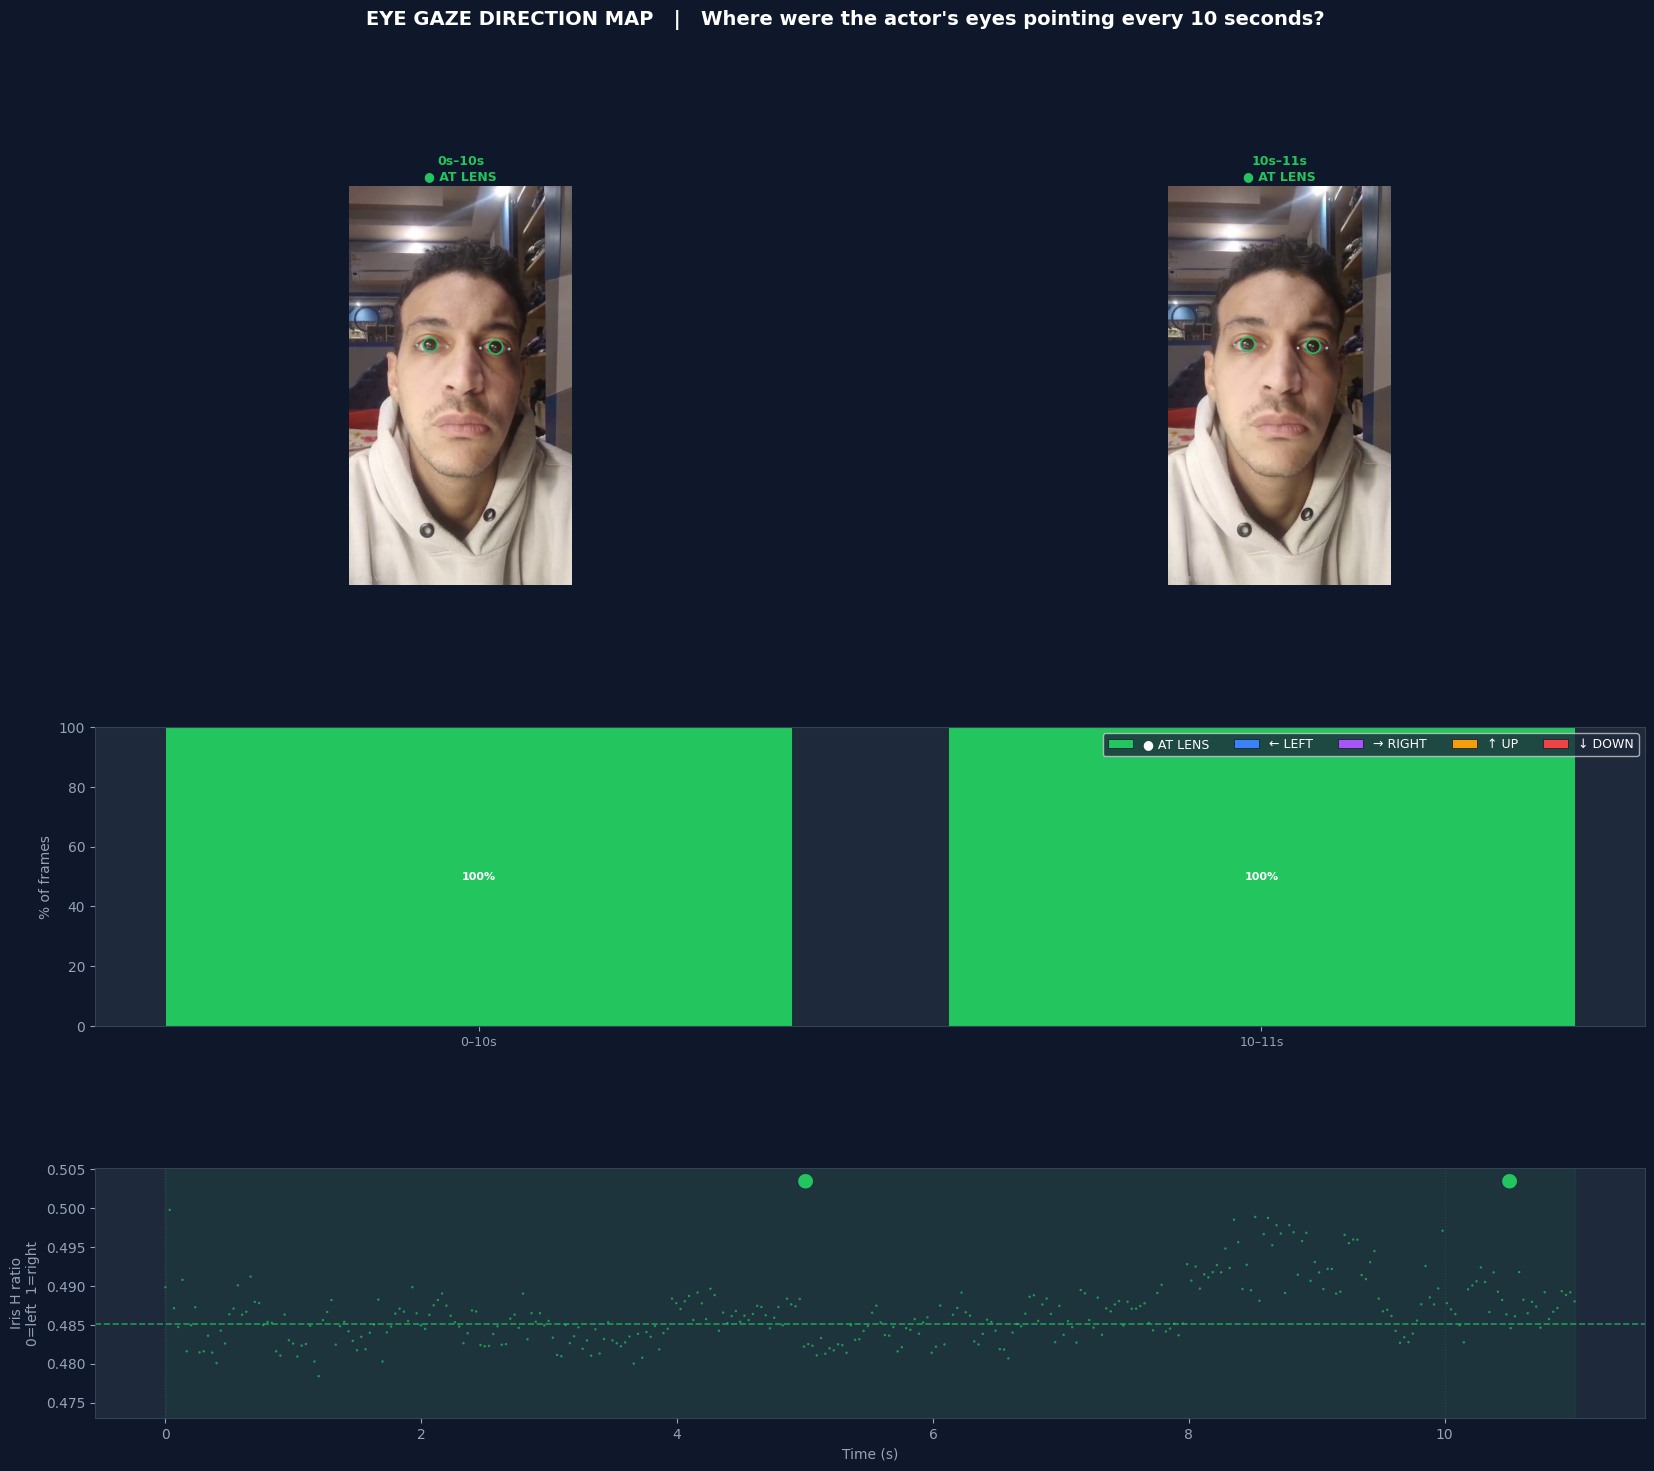

Saved → metric_eye_gaze_direction.png


In [66]:
# ============================================================
# METRIC — Eye Gaze Direction (Iris-Based)
# ============================================================
# Detects where the actor's EYES are pointing every 10 seconds
# using iris landmark position relative to eye socket corners.
#
# This is different from head pose (Metric 1) — it measures
# actual eyeball direction inside the socket, not which way
# the head is turned.
#
# METHOD:
#   For each eye, MediaPipe gives us:
#     - Iris center      → landmarks 468 (right), 473 (left)
#     - Eye corners      → inner/outer horizontal landmarks
#     - Eyelid top/bottom → vertical landmarks
#
#   Horizontal ratio = (iris_x - inner_corner_x) / eye_width
#     → 0.0 = all the way left, 0.5 = center, 1.0 = all the way right
#
#   Vertical ratio = (iris_y - top_lid_y) / eye_height
#     → 0.0 = all the way up, 0.5 = center, 1.0 = all the way down
#
#   Both ratios are averaged across left and right eye.
#
# CALIBRATION:
#   The actor's own neutral gaze center (KDE peak of all
#   frames) is computed per-video, so thresholds adapt to
#   each person's natural resting position.
#
# OUTPUT:
#   Per 10-second window: dominant direction + % breakdown
#   Visualization: thumbnail row + stacked bar + iris trace
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from scipy.stats import gaussian_kde

# ============================================================
# IRIS AND EYE SOCKET LANDMARK INDICES (MediaPipe Face Mesh)
# refine_landmarks=True must be enabled — already set in Step 1
# ============================================================

# Right eye (from actor's perspective)
RIGHT_EYE = {
    "iris":         468,   # iris center
    "inner_corner": 133,   # nose-side corner
    "outer_corner":  33,   # ear-side corner
    "top_lid":      159,   # upper eyelid center
    "bot_lid":      145,   # lower eyelid center
}

# Left eye (from actor's perspective)
LEFT_EYE = {
    "iris":         473,   # iris center
    "inner_corner": 362,   # nose-side corner
    "outer_corner": 263,   # ear-side corner
    "top_lid":      386,   # upper eyelid center
    "bot_lid":      374,   # lower eyelid center
}


# ============================================================
# STEP 1 — EXTRACT IRIS RATIOS PER FRAME
# ============================================================

def compute_iris_ratio(landmarks, eye):
    """
    Computes normalized iris position within the eye socket.

    h_ratio: 0.0 = far left  │ 0.5 = center │ 1.0 = far right
    v_ratio: 0.0 = far up    │ 0.5 = center │ 1.0 = far down

    Uses normalized MediaPipe coordinates (0–1) directly —
    no pixel conversion needed since we only care about ratios.
    """
    iris   = landmarks[eye["iris"]]
    inner  = landmarks[eye["inner_corner"]]
    outer  = landmarks[eye["outer_corner"]]
    top    = landmarks[eye["top_lid"]]
    bot    = landmarks[eye["bot_lid"]]

    eye_width  = abs(outer.x - inner.x)
    eye_height = abs(bot.y   - top.y)

    if eye_width < 1e-6 or eye_height < 1e-6:
        return None, None

    # Horizontal: how far across the eye socket is the iris?
    left_x  = min(inner.x, outer.x)
    h_ratio = (iris.x - left_x) / eye_width

    # Vertical: how far down the eye socket is the iris?
    top_y   = min(top.y, bot.y)
    v_ratio = (iris.y - top_y) / eye_height

    # Clamp to [0, 1] — tiny outliers from landmark jitter
    h_ratio = float(np.clip(h_ratio, 0.0, 1.0))
    v_ratio = float(np.clip(v_ratio, 0.0, 1.0))

    return h_ratio, v_ratio


def extract_iris_series(report):
    """
    Extracts per-frame iris ratios from all usable frames.

    Returns list of dicts:
      timestamp_ms, h_ratio, v_ratio
      (averaged across left and right eye)
    """
    usable_frames = report["usable_frame_data"]
    iris_series   = []

    for fd in usable_frames:
        lm = fd["landmarks"]

        rh, rv = compute_iris_ratio(lm, RIGHT_EYE)
        lh, lv = compute_iris_ratio(lm, LEFT_EYE)

        # Skip frames where either eye failed
        if None in (rh, rv, lh, lv):
            continue

        # Average both eyes
        h_ratio = (rh + lh) / 2.0
        v_ratio = (rv + lv) / 2.0

        iris_series.append({
            "timestamp_ms": fd["timestamp_ms"],
            "h_ratio":      h_ratio,
            "v_ratio":      v_ratio,
        })

    print(f"\n{'='*50}")
    print(f"  IRIS SERIES EXTRACTED")
    print(f"{'='*50}")
    print(f"  Frames extracted : {len(iris_series)}")
    if iris_series:
        h_vals = [f["h_ratio"] for f in iris_series]
        v_vals = [f["v_ratio"] for f in iris_series]
        print(f"  H ratio range    : {min(h_vals):.3f} → {max(h_vals):.3f}  (0=left, 1=right)")
        print(f"  V ratio range    : {min(v_vals):.3f} → {max(v_vals):.3f}  (0=up,   1=down)")
    print(f"{'='*50}\n")

    return iris_series


# ============================================================
# STEP 2 — CALIBRATE NEUTRAL GAZE CENTER (KDE PEAK)
# ============================================================

def calibrate_gaze_center(iris_series):
    """
    Finds the actor's natural resting gaze using KDE peak.

    KDE (kernel density estimation) finds the densest cluster
    of iris positions — this is the neutral "looking at lens"
    position for this actor in this video.

    Using the median would fail when the actor spends most
    of the video looking in one direction (the median would
    shift toward that direction and call it neutral).

    Tolerance = 2× std of frames near the center.
    Safety floor: 0.08 horizontal, 0.10 vertical.
    """

    h_vals = np.array([f["h_ratio"] for f in iris_series])
    v_vals = np.array([f["v_ratio"] for f in iris_series])

    def kde_peak(values):
        kde      = gaussian_kde(values, bw_method=0.2)
        x_grid   = np.linspace(values.min(), values.max(), 500)
        return float(x_grid[np.argmax(kde(x_grid))])

    center_h = kde_peak(h_vals)
    center_v = kde_peak(v_vals)

    # Tolerance from std of near-center frames only
    near_h = h_vals[np.abs(h_vals - center_h) < 0.15]
    near_v = v_vals[np.abs(v_vals - center_v) < 0.15]

    h_tol = max(float(np.std(near_h)) * 2.0, 0.08) if len(near_h) > 5 else 0.10
    v_tol = max(float(np.std(near_v)) * 2.0, 0.10) if len(near_v) > 5 else 0.12

    print(f"  Neutral gaze center  :  H={center_h:.3f}  V={center_v:.3f}")
    print(f"  AT LENS tolerance    : ±H={h_tol:.3f}  ±V={v_tol:.3f}")

    return center_h, center_v, h_tol, v_tol


# ============================================================
# STEP 3 — CLASSIFY GAZE DIRECTION PER FRAME
# ============================================================

def classify_gaze(h_ratio, v_ratio, center_h, center_v, h_tol, v_tol):
    """
    Classifies iris position relative to the actor's own
    neutral gaze center.

    h deviation < 0  → looking LEFT  (iris moved toward nose side)
    h deviation > 0  → looking RIGHT (iris moved toward ear side)
    v deviation < 0  → looking UP    (iris moved toward top lid)
    v deviation > 0  → looking DOWN  (iris moved toward bottom lid)

    When both axes are within tolerance → AT LENS.
    When both axes are outside tolerance → dominant axis wins.
    """
    dh = h_ratio - center_h   # positive = right, negative = left
    dv = v_ratio - center_v   # positive = down,  negative = up

    on_h = abs(dh) <= h_tol
    on_v = abs(dv) <= v_tol

    if on_h and on_v:
        return "AT LENS"

    if on_h:
        return "DOWN" if dv > 0 else "UP"

    if on_v:
        return "RIGHT" if dh > 0 else "LEFT"

    # Both off — whichever deviation is proportionally larger wins
    norm_h = abs(dh) / h_tol
    norm_v = abs(dv) / v_tol

    if norm_h >= norm_v:
        return "RIGHT" if dh > 0 else "LEFT"
    else:
        return "DOWN" if dv > 0 else "UP"


# ============================================================
# STEP 4 — BUCKET INTO 10-SECOND WINDOWS
# ============================================================

def compute_gaze_timeline(iris_series, center_h, center_v,
                           h_tol, v_tol, window_sec=10):
    """
    Groups frames into windows and computes dominant direction
    + full percentage breakdown for each window.
    """
    DIRECTIONS = ["AT LENS", "LEFT", "RIGHT", "UP", "DOWN"]

    timestamps = np.array([f["timestamp_ms"] for f in iris_series])
    h_vals     = np.array([f["h_ratio"]      for f in iris_series])
    v_vals     = np.array([f["v_ratio"]      for f in iris_series])

    duration_sec = timestamps[-1] / 1000
    n_windows    = int(np.ceil(duration_sec / window_sec))
    timeline     = []

    print(f"\n{'='*65}")
    print(f"  EYE GAZE DIRECTION TIMELINE  (window = {window_sec}s)")
    print(f"{'='*65}")

    for w in range(n_windows):
        t_start_ms = w * window_sec * 1000
        t_end_ms   = (w + 1) * window_sec * 1000
        mask       = (timestamps >= t_start_ms) & (timestamps < t_end_ms)

        if np.sum(mask) == 0:
            continue

        labels = [
            classify_gaze(h, v, center_h, center_v, h_tol, v_tol)
            for h, v in zip(h_vals[mask], v_vals[mask])
        ]

        counts    = Counter(labels)
        total     = len(labels)
        dominant  = counts.most_common(1)[0][0]
        breakdown = {d: round(counts.get(d, 0) / total * 100, 1)
                     for d in DIRECTIONS}

        t_end_sec = min((w + 1) * window_sec, duration_sec)
        timeline.append({
            "window":    w,
            "t_start":   w * window_sec,
            "t_end":     t_end_sec,
            "dominant":  dominant,
            "breakdown": breakdown,
            "n_frames":  total,
        })

        print(f"  {w*window_sec:>4.0f}s–{t_end_sec:.0f}s"
              f"  dominant={dominant:<8}"
              f"  LENS={breakdown['AT LENS']:>5.1f}%"
              f"  L={breakdown['LEFT']:>5.1f}%"
              f"  R={breakdown['RIGHT']:>5.1f}%"
              f"  UP={breakdown['UP']:>5.1f}%"
              f"  DN={breakdown['DOWN']:>5.1f}%")

    print(f"{'='*65}\n")
    return timeline


# ============================================================
# STEP 5 — VISUALIZE
# ============================================================

DIR_COLORS = {
    "AT LENS": "#22c55e",
    "LEFT":    "#3b82f6",
    "RIGHT":   "#a855f7",
    "UP":      "#f59e0b",
    "DOWN":    "#ef4444",
}
DIR_ARROWS = {
    "AT LENS": "●",
    "LEFT":    "←",
    "RIGHT":   "→",
    "UP":      "↑",
    "DOWN":    "↓",
}


def visualize_eye_gaze(report, iris_series, timeline,
                        center_h, center_v, h_tol, v_tol,
                        video_path, window_sec=10):
    """
    Three-row visualization:
      Row 1 — Video thumbnail for each window with iris dots
              coloured by dominant direction
      Row 2 — Stacked bar: % breakdown per window
      Row 3 — Iris H ratio trace over time with direction
              colour coding and window markers
    """

    # Timestamp → frame_data lookup (FIX from Metric 1)
    usable_ts_map = {
        fd["timestamp_ms"]: fd
        for fd in report["usable_frame_data"]
    }

    cap        = cv2.VideoCapture(video_path)
    n_windows  = len(timeline)
    DIRECTIONS = ["AT LENS", "LEFT", "RIGHT", "UP", "DOWN"]

    timestamps = np.array([f["timestamp_ms"] for f in iris_series])
    h_vals     = np.array([f["h_ratio"]      for f in iris_series])
    v_vals     = np.array([f["v_ratio"]      for f in iris_series])

    fig = plt.figure(figsize=(max(20, n_windows * 3.8), 16))
    fig.patch.set_facecolor("#0f172a")
    gs  = gridspec.GridSpec(3, n_windows, figure=fig,
                            height_ratios=[1.6, 1.2, 1.0],
                            hspace=0.45, wspace=0.12)

    # ── ROW 1: video thumbnail per window ──────────────────
    for col, win in enumerate(timeline):
        ax     = fig.add_subplot(gs[0, col])
        mid_ms = (win["t_start"] + win["t_end"]) / 2 * 1000

        # Find closest iris_series frame to window midpoint
        ci         = int(np.argmin(np.abs(timestamps - mid_ms)))
        closest_ts = iris_series[ci]["timestamp_ms"]
        fd         = usable_ts_map.get(closest_ts)

        if fd is None:
            ax.axis("off")
            continue

        cap.set(cv2.CAP_PROP_POS_MSEC, fd["timestamp_ms"])
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, w  = frame.shape[:2]
            lm    = fd["landmarks"]
            dom   = win["dominant"]

            c_hex = DIR_COLORS[dom].lstrip("#")
            c_rgb = (int(c_hex[0:2], 16),
                     int(c_hex[2:4], 16),
                     int(c_hex[4:6], 16))

            # Draw iris landmarks coloured by dominant direction
            for iris_idx in [468, 473]:
                px = int(lm[iris_idx].x * w)
                py = int(lm[iris_idx].y * h)
                radius = max(int(h * 0.018), 6)
                cv2.circle(frame, (px, py), radius, c_rgb, 2)
                cv2.circle(frame, (px, py), 2,      c_rgb, -1)

            # Draw eye corner landmarks for reference
            for corner_idx in [33, 133, 362, 263]:
                px = int(lm[corner_idx].x * w)
                py = int(lm[corner_idx].y * h)
                cv2.circle(frame, (px, py), 3, (180, 180, 180), -1)

            # Overlay H/V ratios for debugging
            h_r = iris_series[ci]["h_ratio"]
            v_r = iris_series[ci]["v_ratio"]
            cv2.putText(frame,
                        f"H:{h_r:.2f} V:{v_r:.2f}",
                        (8, h - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.4, (200, 200, 200), 1)

            ax.imshow(frame)

        dom = win["dominant"]
        ax.set_title(
            f"{win['t_start']:.0f}s–{win['t_end']:.0f}s\n"
            f"{DIR_ARROWS[dom]} {dom}",
            color=DIR_COLORS[dom], fontsize=9,
            fontweight="bold", pad=4
        )
        ax.axis("off")

    # ── ROW 2: stacked bar chart ────────────────────────────
    ax_bar = fig.add_subplot(gs[1, :])
    ax_bar.set_facecolor("#1e293b")
    x_pos  = np.arange(n_windows)
    labels = [f"{w['t_start']:.0f}–{w['t_end']:.0f}s" for w in timeline]
    bottom = np.zeros(n_windows)

    for direction in DIRECTIONS:
        vals = np.array([w["breakdown"][direction] for w in timeline])
        ax_bar.bar(x_pos, vals, bottom=bottom,
                   color=DIR_COLORS[direction],
                   label=f"{DIR_ARROWS[direction]} {direction}",
                   edgecolor="#0f172a", linewidth=0.5)
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 12:
                ax_bar.text(xi, b + v / 2, f"{v:.0f}%",
                            ha="center", va="center",
                            color="white", fontsize=8,
                            fontweight="bold")
        bottom += vals

    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(labels, color="#94a3b8", fontsize=9)
    ax_bar.set_ylabel("% of frames", color="#94a3b8", fontsize=10)
    ax_bar.set_ylim(0, 100)
    ax_bar.tick_params(colors="#94a3b8")
    ax_bar.legend(loc="upper right", facecolor="#1e293b",
                  labelcolor="white", fontsize=9, ncol=5)
    for sp in ax_bar.spines.values():
        sp.set_edgecolor("#334155")

    # ── ROW 3: iris H ratio trace over time ────────────────
    ax_iris = fig.add_subplot(gs[2, :])
    ax_iris.set_facecolor("#1e293b")

    t_sec = timestamps / 1000
    directions = [
        classify_gaze(h, v, center_h, center_v, h_tol, v_tol)
        for h, v in zip(h_vals, v_vals)
    ]
    dot_cols = [DIR_COLORS[d] for d in directions]

    ax_iris.scatter(t_sec, h_vals, c=dot_cols, s=3,
                    alpha=0.7, linewidths=0)

    # Neutral center line and tolerance band
    ax_iris.axhline(center_h, color="#22c55e", linewidth=1.2,
                    linestyle="--", alpha=0.7, label="Neutral H")
    ax_iris.axhline(center_h + h_tol, color="#334155",
                    linewidth=0.8, linestyle=":")
    ax_iris.axhline(center_h - h_tol, color="#334155",
                    linewidth=0.8, linestyle=":")
    ax_iris.fill_between(
        [t_sec.min(), t_sec.max()],
        center_h - h_tol, center_h + h_tol,
        color="#22c55e", alpha=0.07
    )

    # Window dividers + dominant arrow above each window
    h_range   = h_vals.max() - h_vals.min() if len(h_vals) > 1 else 0.1
    arrow_y   = h_vals.max() + h_range * 0.15

    for win in timeline:
        ax_iris.axvline(win["t_start"], color="#334155",
                        linewidth=0.8, linestyle=":")
        mid = (win["t_start"] + win["t_end"]) / 2
        ax_iris.text(mid, arrow_y,
                     DIR_ARROWS[win["dominant"]],
                     ha="center",
                     color=DIR_COLORS[win["dominant"]],
                     fontsize=14, fontweight="bold")

    ax_iris.set_xlabel("Time (s)", color="#94a3b8", fontsize=10)
    ax_iris.set_ylabel("Iris H ratio\n0=left  1=right",
                       color="#94a3b8", fontsize=10)
    ax_iris.set_ylim(max(0, h_vals.min() - h_range * 0.25),
                     min(1, arrow_y + h_range * 0.1))
    ax_iris.tick_params(colors="#94a3b8")
    for sp in ax_iris.spines.values():
        sp.set_edgecolor("#334155")

    fig.suptitle(
        "EYE GAZE DIRECTION MAP   |"
        "   Where were the actor's eyes pointing every 10 seconds?",
        color="white", fontsize=14, fontweight="bold", y=0.99
    )

    cap.release()
    plt.savefig("metric_eye_gaze_direction.png", dpi=130,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("Saved → metric_eye_gaze_direction.png")


# ============================================================
# RUN — requires: report, video_filename  (from Step 1)
# ============================================================

iris_series = extract_iris_series(report)

center_h, center_v, h_tol, v_tol = calibrate_gaze_center(iris_series)

gaze_timeline = compute_gaze_timeline(
    iris_series,
    center_h   = center_h,
    center_v   = center_v,
    h_tol      = h_tol,
    v_tol      = v_tol,
    window_sec = 10
)

visualize_eye_gaze(
    report     = report,
    iris_series= iris_series,
    timeline   = gaze_timeline,
    center_h   = center_h,
    center_v   = center_v,
    h_tol      = h_tol,
    v_tol      = v_tol,
    video_path = video_filename,
    window_sec = 10
)



  EMOTION TRANSITIONS DETECTED
  Total transitions : 5
    10s  :  neutral → angry
    20s  :  angry → neutral
    30s  :  neutral → surprised
    40s  :  surprised → neutral
    50s  :  neutral → calm


  EYE GAZE SHIFT AT EMOTION TRANSITIONS

  [✗ ] 10s     neutral → angry     
        Gaze: AT LENS → AT LENS   |  shift: 0.00414
        Volatility: 0.00453 → 0.00558
        Score: 0  (NO_SHIFT)

  [— ] 20s       angry → neutral   
        Not enough frames in window

  [— ] 30s     neutral → surprised 
        Not enough frames in window

  [— ] 40s   surprised → neutral   
        Not enough frames in window

  [— ] 50s     neutral → calm      
        Not enough frames in window

  ────────────────────────────────────────
  Gaze Shift Score : 0.0 / 100



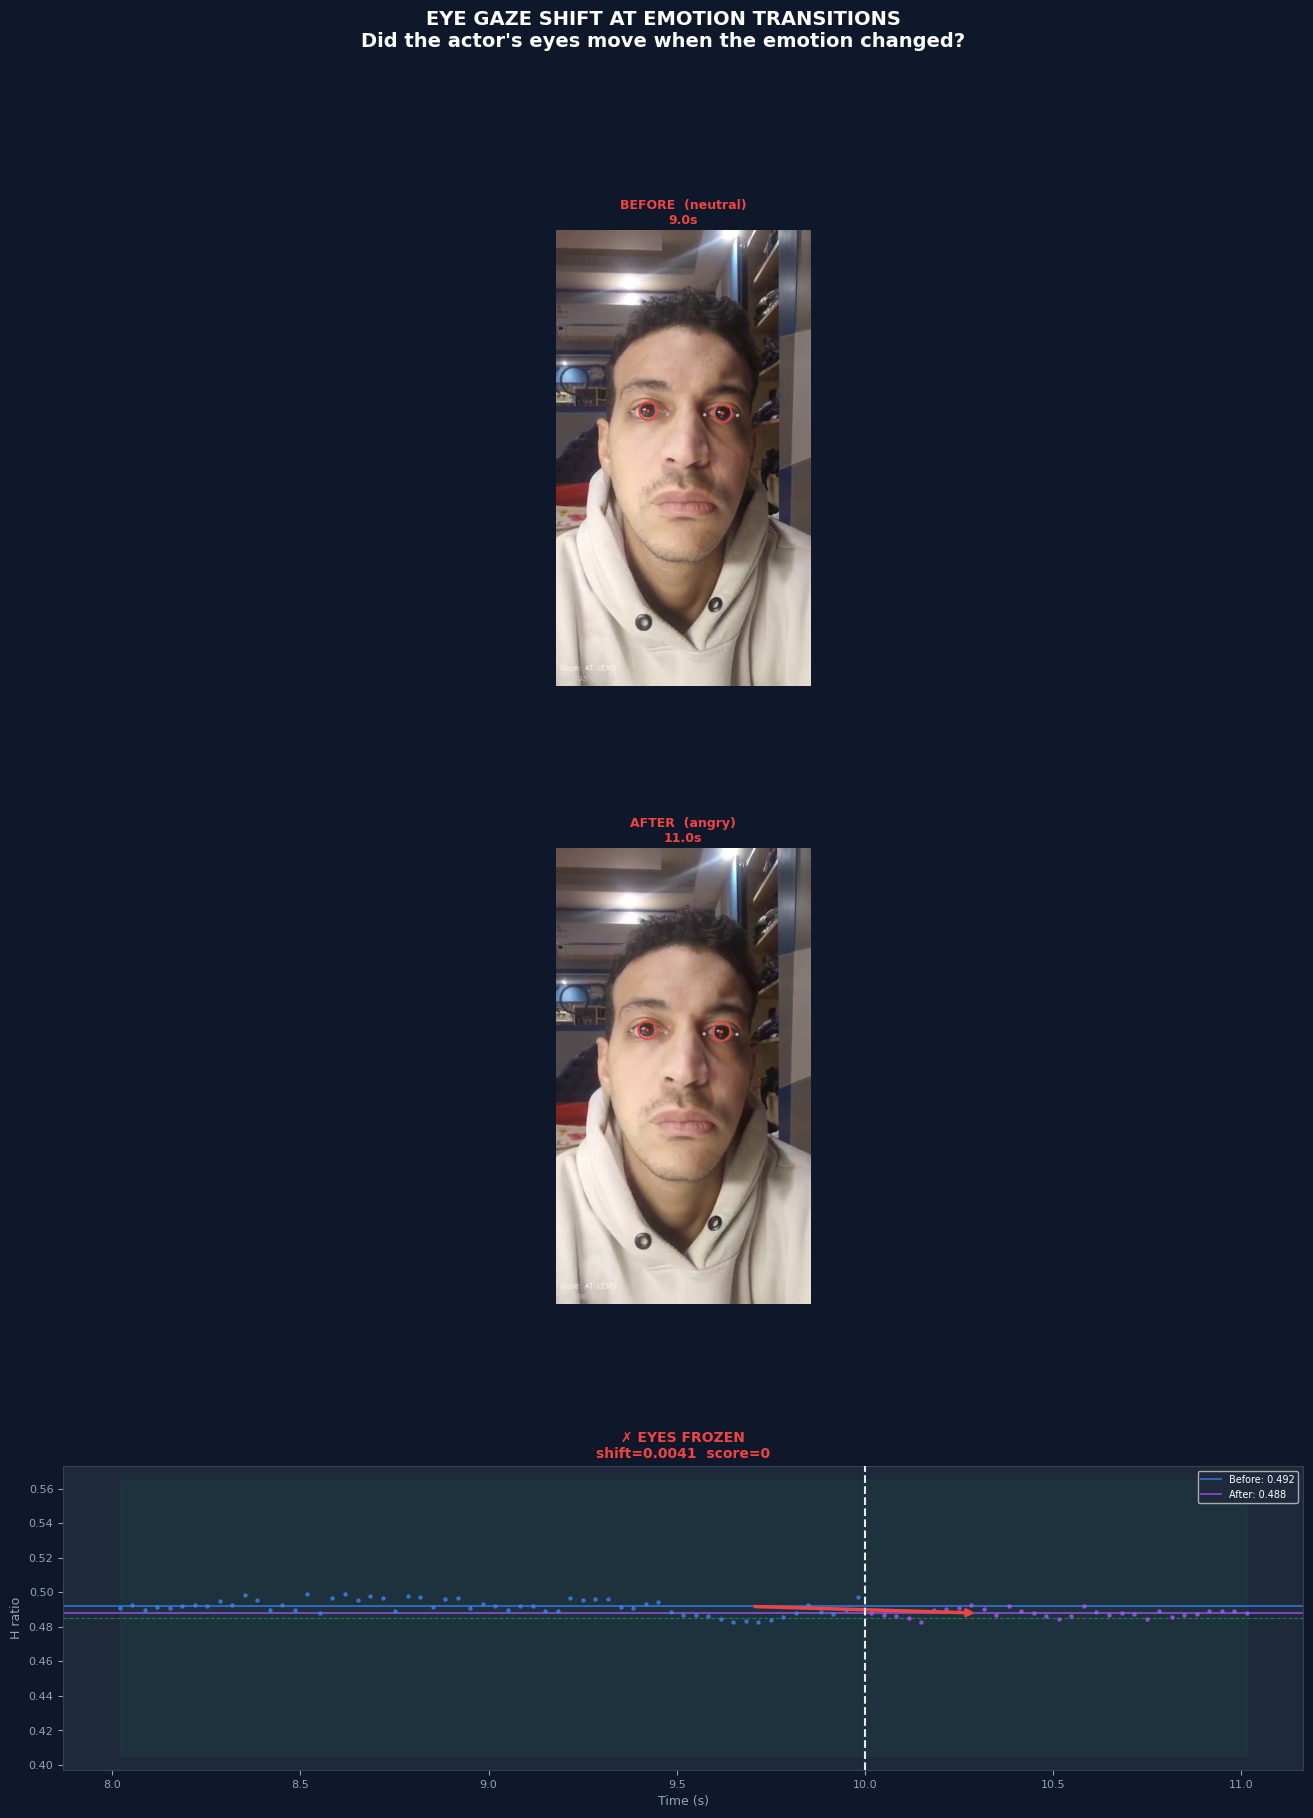

Saved → metric_gaze_shift_transitions.png

GAZE SHIFT SCORE : 0.0 / 100


In [68]:
# ============================================================
# EYE GAZE SHIFT AT EMOTION TRANSITIONS
# ============================================================
# Detects whether the actor's gaze DIRECTION changed when
# the detected emotion transitioned — a key indicator of
# genuine emotional engagement vs surface-level acting.
#
# Uses the head-pose-normalized iris ratios (from the
# previous cell) rather than raw iris position, so the
# measurement is independent of head movement.
#
# WHY THIS MATTERS:
#   A skilled actor's eyes physically shift when their
#   internal emotional state changes — saccades triggered
#   by genuine thought transitions. A flat performer's
#   eyes stay locked in place during emotion changes.
#
# VISUALIZATION:
#   Shows the actual video frame BEFORE and AFTER each
#   transition, with iris landmarks highlighted, so you
#   can visually confirm whether the eyes moved.
#
# INPUTS (from previous cells):
#   iris_series      — per-frame iris H/V ratios
#   EMOTION_TIMELINE — emotion labels per window
#   center_h/v       — actor's neutral gaze center
#   h_tol / v_tol    — gaze tolerance bands
#   report           — usable frame data
#   video_filename   — path to video file
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ============================================================
# CONFIGURATION
# ============================================================

# Seconds before and after each transition to analyze
SHIFT_WINDOW_SEC = 2.0

# Minimum iris ratio displacement to count as a gaze shift
# In normalized eye-socket coordinates (0–1 range)
SHIFT_THRESHOLD_STRONG = 0.015   # clear gaze shift
SHIFT_THRESHOLD_SUBTLE = 0.005   # subtle but measurable


# ============================================================
# STEP 1 — FIND EMOTION TRANSITIONS
# ============================================================
EMOTION_TIMELINE = [
    (0.0,  10.0,  "neutral"),
    (10.0, 20.0,  "angry"),
    (20.0, 30.0,  "neutral"),
    (30.0, 40.0,  "surprised"),
    (40.0, 50.0,  "neutral"),
    (50.0, 61.5,  "calm"),
]

def find_emotion_transitions(emotion_timeline):
    """
    Identifies the exact moments where the detected emotion
    changes. Returns a list of transition dicts.
    """
    transitions = []
    for i in range(1, len(emotion_timeline)):
        prev_start, prev_end, prev_emotion = emotion_timeline[i-1]
        curr_start, curr_end, curr_emotion = emotion_timeline[i]
        if prev_emotion.lower().strip() != curr_emotion.lower().strip():
            transitions.append({
                "time_sec":     curr_start,
                "time_ms":      curr_start * 1000,
                "from_emotion": prev_emotion,
                "to_emotion":   curr_emotion,
            })

    print(f"\n{'='*55}")
    print(f"  EMOTION TRANSITIONS DETECTED")
    print(f"{'='*55}")
    print(f"  Total transitions : {len(transitions)}")
    for t in transitions:
        print(f"    {t['time_sec']:.0f}s  :  "
              f"{t['from_emotion']} → {t['to_emotion']}")
    print(f"{'='*55}\n")

    return transitions


# ============================================================
# STEP 2 — MEASURE GAZE SHIFT AT EACH TRANSITION
# ============================================================

def measure_gaze_shifts(iris_series, transitions,
                        center_h, center_v, h_tol, v_tol,
                        window_sec=SHIFT_WINDOW_SEC):
    """
    For each transition, compares the average gaze direction
    in a window BEFORE vs AFTER the transition point.

    Metrics per transition:
      - displacement    : Euclidean shift in (h, v) ratio space
      - direction_from  : classified gaze before
      - direction_to    : classified gaze after
      - volatility      : avg frame-to-frame iris movement
      - score           : 0 / 50 / 100
    """

    timestamps = np.array([f["timestamp_ms"] for f in iris_series])
    h_vals     = np.array([f["h_ratio"]      for f in iris_series])
    v_vals     = np.array([f["v_ratio"]      for f in iris_series])

    window_ms = window_sec * 1000
    results   = []

    for t in transitions:
        t_ms = t["time_ms"]

        # Frames in the window before transition
        before_mask = ((timestamps >= t_ms - window_ms) &
                       (timestamps < t_ms))
        # Frames in the window after transition
        after_mask  = ((timestamps >= t_ms) &
                       (timestamps <= t_ms + window_ms))

        if np.sum(before_mask) < 3 or np.sum(after_mask) < 3:
            results.append({
                **t,
                "displacement": None,
                "score": None,
                "label": "NO_DATA",
                "message": "Not enough frames in window",
            })
            continue

        # Average gaze position before and after
        h_before = np.mean(h_vals[before_mask])
        v_before = np.mean(v_vals[before_mask])
        h_after  = np.mean(h_vals[after_mask])
        v_after  = np.mean(v_vals[after_mask])

        # Displacement in iris-ratio space
        displacement = np.sqrt(
            (h_after - h_before)**2 + (v_after - v_before)**2
        )

        # Volatility (avg frame-to-frame movement)
        h_b = h_vals[before_mask]
        v_b = v_vals[before_mask]
        h_a = h_vals[after_mask]
        v_a = v_vals[after_mask]
        vol_before = np.mean(
            np.sqrt(np.diff(h_b)**2 + np.diff(v_b)**2)
        )
        vol_after = np.mean(
            np.sqrt(np.diff(h_a)**2 + np.diff(v_a)**2)
        )

        # Classify gaze direction before and after
        dir_before = classify_gaze(
            h_before, v_before,
            center_h, center_v, h_tol, v_tol
        )
        dir_after = classify_gaze(
            h_after, v_after,
            center_h, center_v, h_tol, v_tol
        )

        # Score the transition
        if displacement >= SHIFT_THRESHOLD_STRONG:
            score = 100.0
            label = "STRONG_SHIFT"
        elif displacement >= SHIFT_THRESHOLD_SUBTLE:
            score = 50.0
            label = "SUBTLE_SHIFT"
        else:
            score = 0.0
            label = "NO_SHIFT"

        results.append({
            **t,
            "displacement":   round(displacement, 5),
            "h_before":       round(h_before, 4),
            "v_before":       round(v_before, 4),
            "h_after":        round(h_after, 4),
            "v_after":        round(v_after, 4),
            "dir_before":     dir_before,
            "dir_after":      dir_after,
            "vol_before":     round(vol_before, 5),
            "vol_after":      round(vol_after, 5),
            "score":          score,
            "label":          label,
        })

    # ── Print report ──────────────────────────────────────
    ICONS = {
        "STRONG_SHIFT": "✓✓",
        "SUBTLE_SHIFT": "✓ ",
        "NO_SHIFT":     "✗ ",
        "NO_DATA":      "— ",
    }

    scored = [r for r in results if r["score"] is not None]
    final_score = (
        np.mean([r["score"] for r in scored])
        if scored else 0.0
    )

    print(f"\n{'='*60}")
    print(f"  EYE GAZE SHIFT AT EMOTION TRANSITIONS")
    print(f"{'='*60}")

    for r in results:
        icon = ICONS.get(r["label"], "?")
        if r["displacement"] is not None:
            print(
                f"\n  [{icon}] {r['time_sec']:.0f}s  "
                f"{r['from_emotion']:>10} → "
                f"{r['to_emotion']:<10}"
            )
            print(
                f"        Gaze: {r['dir_before']} → "
                f"{r['dir_after']}   |  "
                f"shift: {r['displacement']:.5f}"
            )
            print(
                f"        Volatility: "
                f"{r['vol_before']:.5f} → "
                f"{r['vol_after']:.5f}"
            )
            print(
                f"        Score: {r['score']:.0f}  "
                f"({r['label']})"
            )
        else:
            print(
                f"\n  [{icon}] {r['time_sec']:.0f}s  "
                f"{r['from_emotion']:>10} → "
                f"{r['to_emotion']:<10}"
            )
            print(f"        {r['message']}")

    print(f"\n  {'─'*40}")
    print(f"  Gaze Shift Score : {final_score:.1f} / 100")
    print(f"{'='*60}\n")

    return results, round(final_score, 2)


# ============================================================
# STEP 3 — VISUALIZE WITH VIDEO FRAMES
# ============================================================

SHIFT_COLORS = {
    "STRONG_SHIFT": "#22c55e",   # green — eyes moved
    "SUBTLE_SHIFT": "#f59e0b",   # amber — subtle
    "NO_SHIFT":     "#ef4444",   # red   — frozen
    "NO_DATA":      "#64748b",   # gray
}

SHIFT_LABELS = {
    "STRONG_SHIFT": "✓ EYES MOVED",
    "SUBTLE_SHIFT": "~ SUBTLE SHIFT",
    "NO_SHIFT":     "✗ EYES FROZEN",
    "NO_DATA":      "— NO DATA",
}


def _draw_transition_frame(ax, cap, iris_series,
                            usable_ts_map, frame_idx,
                            color, title, direction):
    """Draw a single video frame with iris landmarks."""

    ts = iris_series[frame_idx]["timestamp_ms"]
    fd = usable_ts_map.get(ts)

    if fd is None:
        ax.set_facecolor("#1e293b")
        ax.text(0.5, 0.5, "No frame",
                ha="center", va="center",
                color="white", fontsize=12,
                transform=ax.transAxes)
        ax.axis("off")
        return

    cap.set(cv2.CAP_PROP_POS_MSEC, fd["timestamp_ms"])
    ret, frame = cap.read()

    if not ret:
        ax.set_facecolor("#1e293b")
        ax.text(0.5, 0.5, "Read error",
                ha="center", va="center",
                color="white", fontsize=12,
                transform=ax.transAxes)
        ax.axis("off")
        return

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    h, w  = frame.shape[:2]
    lm    = fd["landmarks"]

    # Parse color hex → RGB tuple
    c_hex = color.lstrip("#")
    c_rgb = (int(c_hex[0:2], 16),
             int(c_hex[2:4], 16),
             int(c_hex[4:6], 16))

    # Draw iris landmarks
    for iris_idx in [468, 473]:
        px = int(lm[iris_idx].x * w)
        py = int(lm[iris_idx].y * h)
        radius = max(int(h * 0.02), 7)
        cv2.circle(frame, (px, py), radius, c_rgb, 2)
        cv2.circle(frame, (px, py), 3, c_rgb, -1)

    # Draw eye corners for reference
    for corner_idx in [33, 133, 362, 263]:
        px = int(lm[corner_idx].x * w)
        py = int(lm[corner_idx].y * h)
        cv2.circle(frame, (px, py), 3,
                   (180, 180, 180), -1)

    # Overlay gaze direction and H/V ratios
    h_r = iris_series[frame_idx]["h_ratio"]
    v_r = iris_series[frame_idx]["v_ratio"]
    cv2.putText(
        frame, f"Gaze: {direction}",
        (8, h - 30), cv2.FONT_HERSHEY_SIMPLEX,
        0.45, (255, 255, 255), 1
    )
    cv2.putText(
        frame, f"H:{h_r:.3f} V:{v_r:.3f}",
        (8, h - 10), cv2.FONT_HERSHEY_SIMPLEX,
        0.40, (200, 200, 200), 1
    )

    ax.imshow(frame)
    ax.set_title(title, color=color, fontsize=9,
                 fontweight="bold", pad=4)
    ax.axis("off")


def visualize_gaze_transitions(report, iris_series,
                                results,
                                center_h, center_v,
                                h_tol, v_tol,
                                video_path,
                                window_sec=SHIFT_WINDOW_SEC):
    """
    For each transition shows:
      Row 1 — Video frame BEFORE transition (with iris)
      Row 2 — Video frame AFTER  transition (with iris)
      Row 3 — Iris H-ratio trace through the window
              with shift arrow and score badge
    """

    valid = [r for r in results
             if r["displacement"] is not None]
    if len(valid) == 0:
        print("No valid transitions to visualize.")
        return

    n_cols = len(valid)

    # Timestamp → frame_data lookup
    usable_ts_map = {
        fd["timestamp_ms"]: fd
        for fd in report["usable_frame_data"]
    }

    timestamps = np.array(
        [f["timestamp_ms"] for f in iris_series]
    )
    h_vals = np.array(
        [f["h_ratio"] for f in iris_series]
    )
    v_vals = np.array(
        [f["v_ratio"] for f in iris_series]
    )

    window_ms = window_sec * 1000
    cap       = cv2.VideoCapture(video_path)

    fig = plt.figure(
        figsize=(max(16, n_cols * 5.5), 20)
    )
    fig.patch.set_facecolor("#0f172a")

    gs = gridspec.GridSpec(
        3, n_cols, figure=fig,
        height_ratios=[1.5, 1.5, 1.0],
        hspace=0.40, wspace=0.20
    )

    for col, r in enumerate(valid):
        t_ms  = r["time_ms"]
        color = SHIFT_COLORS[r["label"]]

        # ── Find best frames before and after ──────
        before_mask = (
            (timestamps >= t_ms - window_ms) &
            (timestamps < t_ms)
        )
        after_mask = (
            (timestamps >= t_ms) &
            (timestamps <= t_ms + window_ms)
        )

        before_idx = np.where(before_mask)[0]
        after_idx  = np.where(after_mask)[0]

        if len(before_idx) == 0 or len(after_idx) == 0:
            continue

        # Pick frame ~1 sec before and ~1 sec after
        target_before_ms = t_ms - 1000
        target_after_ms  = t_ms + 1000

        best_before = before_idx[
            np.argmin(np.abs(
                timestamps[before_idx] -
                target_before_ms
            ))
        ]
        best_after = after_idx[
            np.argmin(np.abs(
                timestamps[after_idx] -
                target_after_ms
            ))
        ]

        # ── ROW 1: BEFORE FRAME ────────────────────
        ax_before = fig.add_subplot(gs[0, col])
        _draw_transition_frame(
            ax_before, cap, iris_series,
            usable_ts_map, best_before, color,
            f"BEFORE  ({r['from_emotion']})\n"
            f"{timestamps[best_before]/1000:.1f}s",
            r["dir_before"]
        )

        # ── ROW 2: AFTER FRAME ─────────────────────
        ax_after = fig.add_subplot(gs[1, col])
        _draw_transition_frame(
            ax_after, cap, iris_series,
            usable_ts_map, best_after, color,
            f"AFTER  ({r['to_emotion']})\n"
            f"{timestamps[best_after]/1000:.1f}s",
            r["dir_after"]
        )

        # ── ROW 3: IRIS TRACE IN WINDOW ────────────
        ax_trace = fig.add_subplot(gs[2, col])
        ax_trace.set_facecolor("#1e293b")

        # Full window mask
        full_mask = (
            (timestamps >= t_ms - window_ms) &
            (timestamps <= t_ms + window_ms)
        )
        t_sec = timestamps[full_mask] / 1000
        h_win = h_vals[full_mask]

        # Color-code before (blue) / after (purple)
        for i_pt in range(len(t_sec)):
            c = ("#3b82f6"
                 if t_sec[i_pt] < r["time_sec"]
                 else "#a855f7")
            ax_trace.scatter(
                t_sec[i_pt], h_win[i_pt],
                c=c, s=5, alpha=0.7, zorder=3
            )

        # Transition line
        ax_trace.axvline(
            r["time_sec"], color="white",
            linewidth=1.5, linestyle="--",
            alpha=0.9, zorder=4
        )

        # Neutral band
        ax_trace.axhline(
            center_h, color="#22c55e",
            linewidth=0.8, linestyle="--",
            alpha=0.5
        )
        ax_trace.fill_between(
            [t_sec.min(), t_sec.max()],
            center_h - h_tol, center_h + h_tol,
            color="#22c55e", alpha=0.06
        )

        # Mean lines before / after
        ax_trace.axhline(
            r["h_before"], color="#3b82f6",
            linewidth=1.2, linestyle="-",
            alpha=0.8,
            label=f'Before: {r["h_before"]:.3f}'
        )
        ax_trace.axhline(
            r["h_after"], color="#a855f7",
            linewidth=1.2, linestyle="-",
            alpha=0.8,
            label=f'After: {r["h_after"]:.3f}'
        )

        # Shift arrow
        mid_t = r["time_sec"]
        ax_trace.annotate(
            "",
            xy=(mid_t + 0.3, r["h_after"]),
            xytext=(mid_t - 0.3, r["h_before"]),
            arrowprops=dict(
                arrowstyle="->",
                color=color, lw=2.5
            )
        )

        ax_trace.set_xlabel(
            "Time (s)", color="#94a3b8",
            fontsize=9
        )
        ax_trace.set_ylabel(
            "H ratio", color="#94a3b8",
            fontsize=9
        )
        ax_trace.tick_params(
            colors="#94a3b8", labelsize=8
        )
        for sp in ax_trace.spines.values():
            sp.set_edgecolor("#334155")

        # Result badge as title
        badge = SHIFT_LABELS[r["label"]]
        ax_trace.set_title(
            f"{badge}\n"
            f"shift={r['displacement']:.4f}  "
            f"score={r['score']:.0f}",
            color=color, fontsize=10,
            fontweight="bold", pad=6
        )

        ax_trace.legend(
            loc="upper right", fontsize=7,
            facecolor="#1e293b",
            labelcolor="white"
        )

    fig.suptitle(
        "EYE GAZE SHIFT AT EMOTION TRANSITIONS\n"
        "Did the actor's eyes move when the "
        "emotion changed?",
        color="white", fontsize=14,
        fontweight="bold", y=0.99
    )

    cap.release()
    plt.savefig(
        "metric_gaze_shift_transitions.png",
        dpi=130, bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.show()
    print("Saved → metric_gaze_shift_transitions.png")


# ============================================================
# RUN
# ============================================================
# Requires from previous cells:
#   report, iris_series, EMOTION_TIMELINE,
#   center_h, center_v, h_tol, v_tol, video_filename
# ============================================================

transitions = find_emotion_transitions(EMOTION_TIMELINE)

shift_results, shift_score = measure_gaze_shifts(
    iris_series, transitions,
    center_h, center_v, h_tol, v_tol,
    window_sec=SHIFT_WINDOW_SEC
)

visualize_gaze_transitions(
    report      = report,
    iris_series = iris_series,
    results     = shift_results,
    center_h    = center_h,
    center_v    = center_v,
    h_tol       = h_tol,
    v_tol       = v_tol,
    video_path  = video_filename,
    window_sec  = SHIFT_WINDOW_SEC
)

print(f"\nGAZE SHIFT SCORE : {shift_score} / 100")
